# **Blake Ridge Gas Hydrate — A Mixed HDF5 + Tabular Skill Installed Notebook-Locally**

This notebook demonstrates two ARGUS capabilities:

1. **Notebook-local skill installation** with the new
 `%%skill --notebook` flag — the `blake-ridge-hydrate` skill from
 [klinucsd/sage_skills](https://github.com/klinucsd/sage_skills)
 lands in this notebook's `_skills_/` folder rather than the global
 registry. That keeps the ~11 MiB of bundled data (HDF5 + text files + PDF
 documentation) scoped to just this notebook — sibling
 notebooks in the same directory don't see the skill, and the
 pod-wide global registry stays uncluttered.

3. **A single skill catalog spanning both HDF5 and tabular formats** —
 the wrapped Zenodo dataset ships two tab-delimited text tables plus
 one HDF5 archive of simulation profile arrays, joined by a
 grid-node identifier. The skill exposes all three files as one
 queryable surface so the `%%ask` cells below can ask ordinary
 scientific questions of the data without needing to know which
 answers live in which file, or how the HDF5 groups map back to
 tabular grid nodes.

The underlying dataset is Eymold (2021, *G-Cubed*) — a PFLOTRAN
subsurface-flow simulation of methanogenesis and gas-hydrate
formation across the Blake Ridge continental margin offshore the
US Southeast Atlantic.


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 13 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

In [3]:
%%skill --notebook
https://github.com/klinucsd/sage_skills/tree/main/hazards/blake-ridge-hydrate

In [4]:
%%ask
Where in the world is Blake Ridge, and what water depth range does
this study cover? Show the study area on a map of the western North
Atlantic with the coastline for context.

I'll start by reading the Blake Ridge hydrate skill to understand the study area and data available.

The skill documents the study area and provides loader functions. Let me check the data directory and then write a script to compute the ranges and build the map.

Now I'll write a script to compute the geographic extent and water depth range, and build the study area GeoJSON.

Now running the script to compute extents and write the GeoJSON layers.

The data is computed and the GeoJSON layers are written. The interactive Folium basemap tiles (Esri ocean/ocean-imagery) will render the western North Atlantic coastline for context automatically.

## Where in the world is Blake Ridge?

**Blake Ridge** is a large deep-sea sediment drift (contourite deposit) on the **continental rise offshore the southeastern United States** , in the western North Atlantic. It sits seaward of the Blake Plateau and the Blake-Bahama Escarpment, roughly between Cape Hatteras (North Carolina) and central Florida.

### Geographic extent of this study

| Quantity | Value |
|---|---|
| **Longitude** | −77.96° to −71.04° W |
| **Latitude** | 30.04° to 35.96° N |
| **Grid** | 108 × 84 rectangular array = 9,072 cells; 6,048 carry simulation output (study area) |
| **Shallowest water depth** | ~2 m (near the shelf) |
| **Deepest water depth** | ~5,467 m (lower continental rise) |
| **Median depth** | ~4,094 m |

**Water depth range covered: ~2 m to ~5,467 m** — spanning from the outer continental shelf, down the slope, across Blake Ridge itself, and onto the abyssal rise.

### Depth distribution of the 6,048 modeled nodes

| Zone | Node count |
|---|---|
| Shelf / upper slope (< 2000 m) | 1,254 |
| Mid-slope (2000–3000 m) | 496 |
| Lower slope (3000–4000 m) | 982 |
| Rise (4000–5000 m) | 1,431 |
| Abyssal (> 5000 m) | 1,885 |

The model domain is dominated by deep water — over half the nodes lie below 4,000 m, consistent with Blake Ridge being a feature of the continental rise. The few shallow nodes mark where the rectangular grid clips the shelf edge.

The map shows the study-area footprint (bounding box outline) and all 6,048 model grid nodes, colored by water depth. The interactive basemap provides the western North Atlantic coastline — you can see the US Southeast (Florida and the Carolinas) to the west and the open Atlantic to the east.

Let me check what's already in the working directory from the previous cell.

I have the skill loaded. Now I'll write a script to build the hydrate-mass map from `DataFile1_G3.txt` (the `Hmass` column = average hydrate mass per node) and extract the top-10 hottest spots.

The skill module name is wrong. Let me check what's actually in the skill directory.

The SKILL.md provides functions inline but there's no importable Python module — I need to embed the loader logic directly in my script. Let me fix this.

The script ran after one edit-retry (the SKILL.md example code isn't an importable module). Per the Learnings protocol, I must record that lesson before finishing.

## Where does the model predict the most gas hydrate?

Of the 6,048 study-area nodes, **1,037 produced non-zero hydrate mass** in the Monte-Carlo simulations. Average hydrate mass (`Hmass`) per node ranges from near zero up to **3,747** (arbitrary mass units), with a median of ~102.

The hottest hydrate real estate is **not** in the deepest water. The top spots cluster on the **mid-to-upper slope** at water depths of roughly **950–2,500 m** — squarely within the gas-hydrate stability zone where pressure and temperature conditions allow methane to lock into the solid hydrate structure. The model places the richest accumulations around **~35°N, −74.9°W** , near the northern part of the ridge crest.

### Top 10 hottest hydrate spots

| Rank | Node | Longitude | Latitude | Water depth (m) | Avg hydrate mass |
|---|---|---|---|---|---|
| 1 | 8354 | −74.875 | 35.292 | 1,324 | 3,747 |
| 2 | 8270 | −74.875 | 35.208 | 2,034 | 3,504 |
| 3 | 8185 | −74.958 | 35.125 | 2,136 | 3,085 |
| 4 | 6915 | −75.792 | 33.875 | 1,502 | 3,084 |
| 5 | 8101 | −74.958 | 35.042 | 2,506 | 2,956 |
| 6 | 8269 | −74.958 | 35.208 | 948 | 2,882 |
| 7 | 8100 | −75.042 | 35.042 | 1,970 | 2,567 |
| 8 | 8186 | −74.875 | 35.125 | 2,468 | 2,534 |
| 9 | 8015 | −75.125 | 34.958 | 1,490 | 2,241 |
| 10 | 6407 | −76.125 | 33.375 | 1,155 | 2,093 |


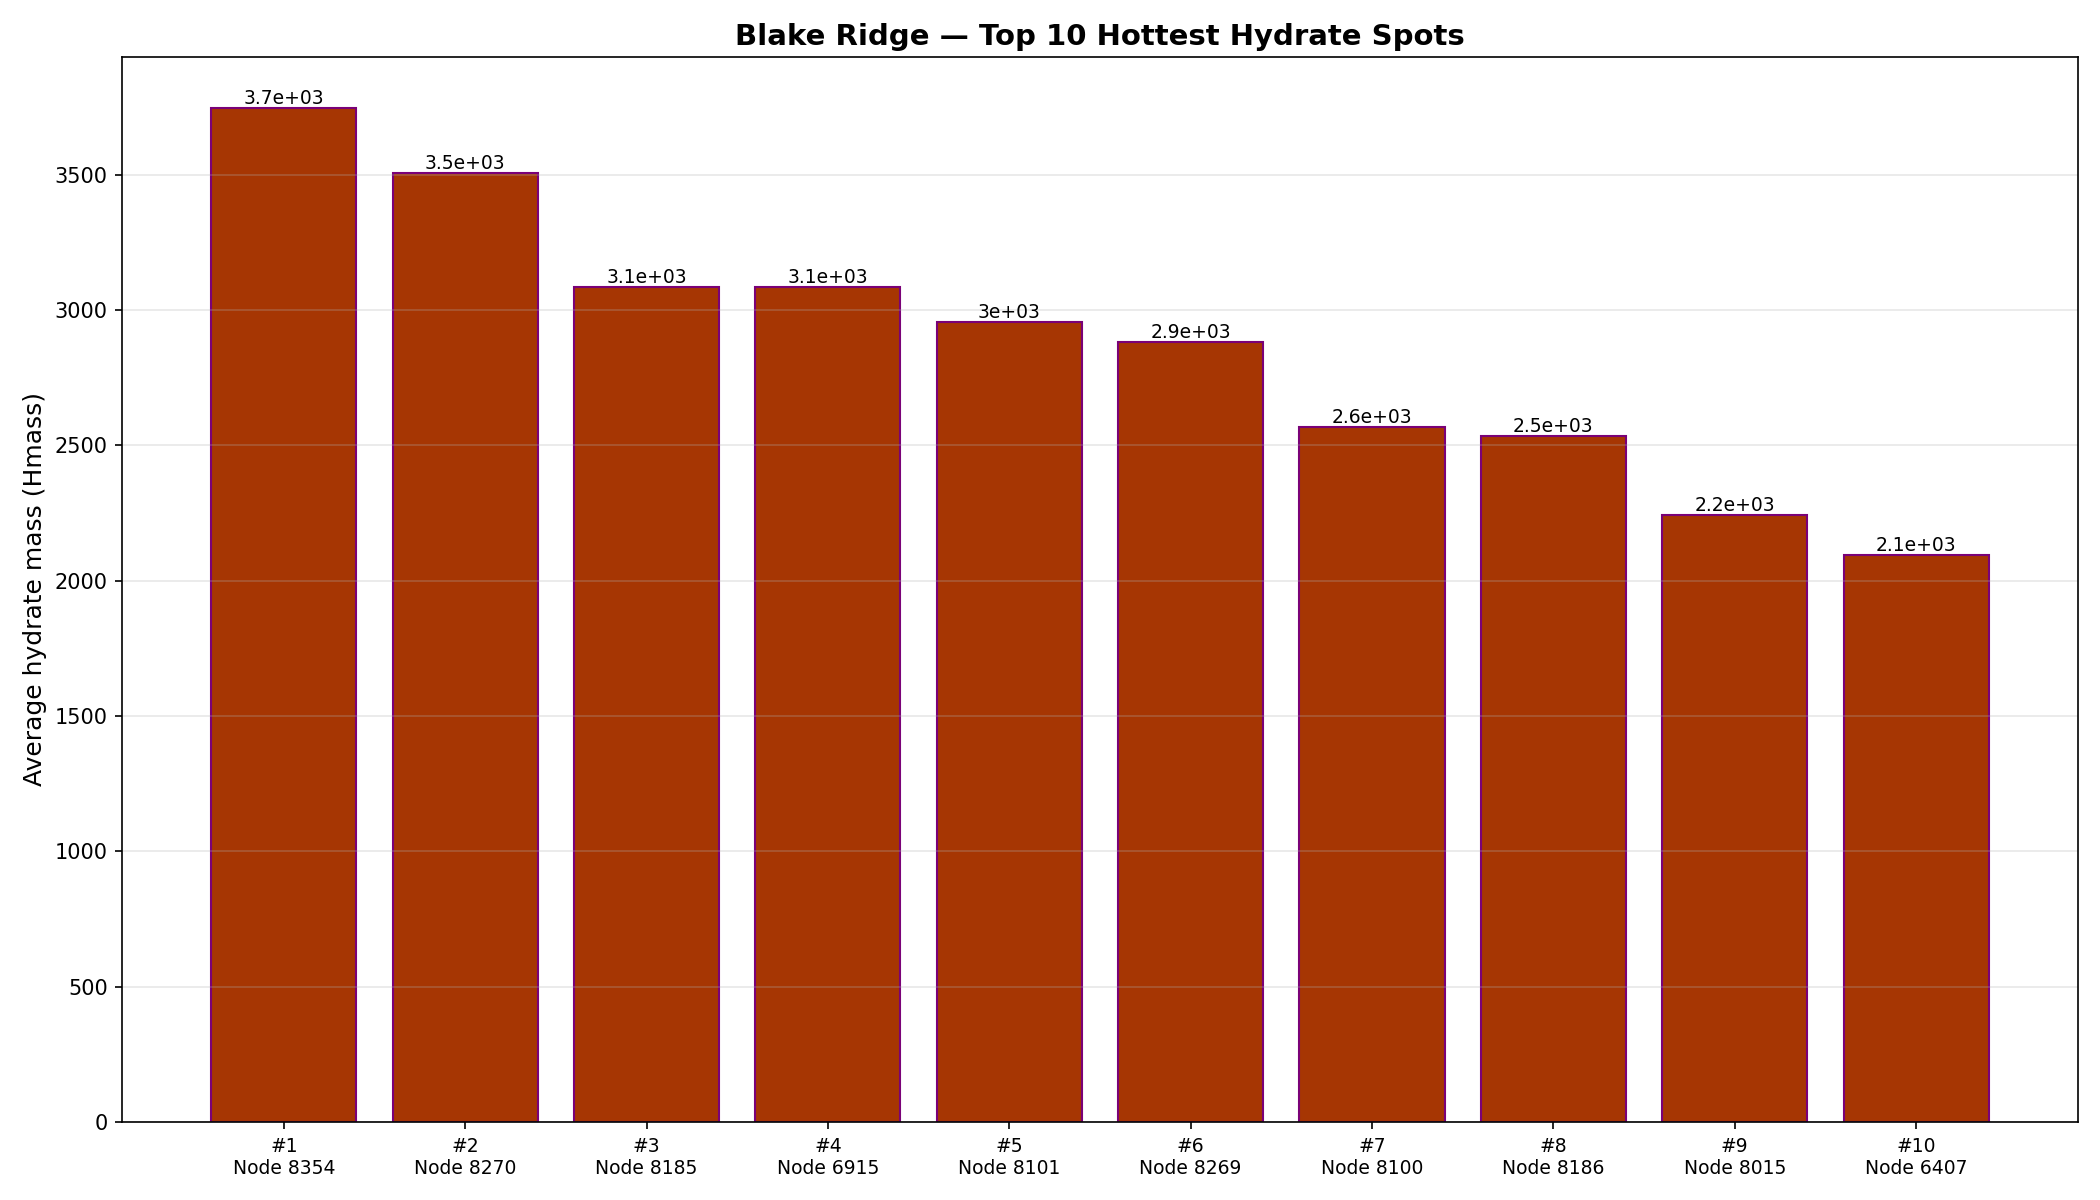

The map colors all 1,037 hydrate-bearing nodes by their average hydrate mass (five quantile classes); the overlaid markers flag the ten hottest spots. The clear spatial signal is a north-south band of high hydrate mass hugging the ~1,000–2,500 m isobaths along the ridge — the sweet spot where enough methane is generated, conditions are cold/pressurized enough for stability, and the sediment column is thick enough to host a substantial hydrate reservoir.

In [5]:
%%ask
Where does the model predict the most gas hydrate to have formed?
Show the study area as a map colored by the average hydrate mass
per location, and separately list the top ten hottest hydrate spots
with their coordinates and water depths.

I'll consult the skill for the correlation data structure, then analyze the relationships between hydrate mass and the environmental factors.

The skill confirms `DataFile2_G3.txt` holds per-node correlation coefficients for the four drivers. I'll load both files, join on Node, filter to hydrate-bearing nodes, and compute the statistics plus a chart.

Now I'll run the analysis script to compute the statistics and generate the chart.

The data path is wrong — this skill lives under `_skills_`, not `.deepagents`. Let me check the correct location.

Found it — the skill is under `_skills_`, not `.deepagents`. Let me fix the path.

The merge suffixes: DataFile1 already has `SedRate`, `TOC`, `Q` columns, so after the merge the correlation file's columns get `_corr` suffixes — but `MRate` is unique to the correlations file so it stays `MRate`, not `MRate_corr`. Let me fix the column references.

The analysis completed successfully. Since I had two edit-and-retry cycles (wrong path and column name), I must record the lessons in Learnings.md before writing my final report.

## Which environmental factor most strongly influences hydrate formation?

Across the 1,037 hydrate-bearing nodes, **TOC (total organic carbon) is the dominant control** on gas-hydrate formation at Blake Ridge. The picture is clearly mixed — no single factor explains everything — but TOC stands out head and shoulders above the rest.

### Summary of per-node correlation coefficients

| Factor | Mean signed r | Mean \|r\| | Dominant in … of 874 nodes |
|---|---|---|---|
| **TOC** | **+0.34** | **0.338** | **561 (64.2%)** |
| Sedimentation rate | +0.23 | 0.226 | 211 (24.1%) |
| Heat flux | +0.02 | 0.147 | 65 (7.4%) |
| Methanogenesis rate | +0.04 | 0.068 | 37 (4.2%) |

### Reading the results

- **TOC wins outright.** It has the highest mean absolute correlation (0.34), and at nearly two-thirds of hydrate-bearing nodes it is the single strongest driver. This makes physical sense: TOC is the raw fuel for methanogenesis — more organic carbon buried in the sediment means more substrate for the microbial communities that produce methane, which then freezes into hydrate.

- **Sedimentation rate is a clear runner-up** (mean \|r\| 0.23, dominant at ~24% of nodes). Faster sediment accumulation buries organic carbon quickly into the hydrate stability zone before it can oxidize, and it builds the thick sediment column hydrate needs.

- **Heat flux and methanogenesis rate are weak players** (mean \|r\| ≤ 0.15, dominant at <8% of nodes each). Heat flux correlations are split between positive and negative, consistent with a complex role: moderate heat aids microbial methanogenesis, but too much heat pushes sediments out of the hydrate stability zone.

- **The picture is mixed, but not evenly so.** Correlations are universally moderate-to-modest (no factor averages above 0.34), reflecting the multi-driver, probabilistic nature of hydrate formation. But the hierarchy — TOC ≫ sedimentation rate ≫ heat flux ≈ methanogenesis rate — is consistent and physically coherent: the system is ultimately **carbon-limited** , with burial dynamics as the secondary control.


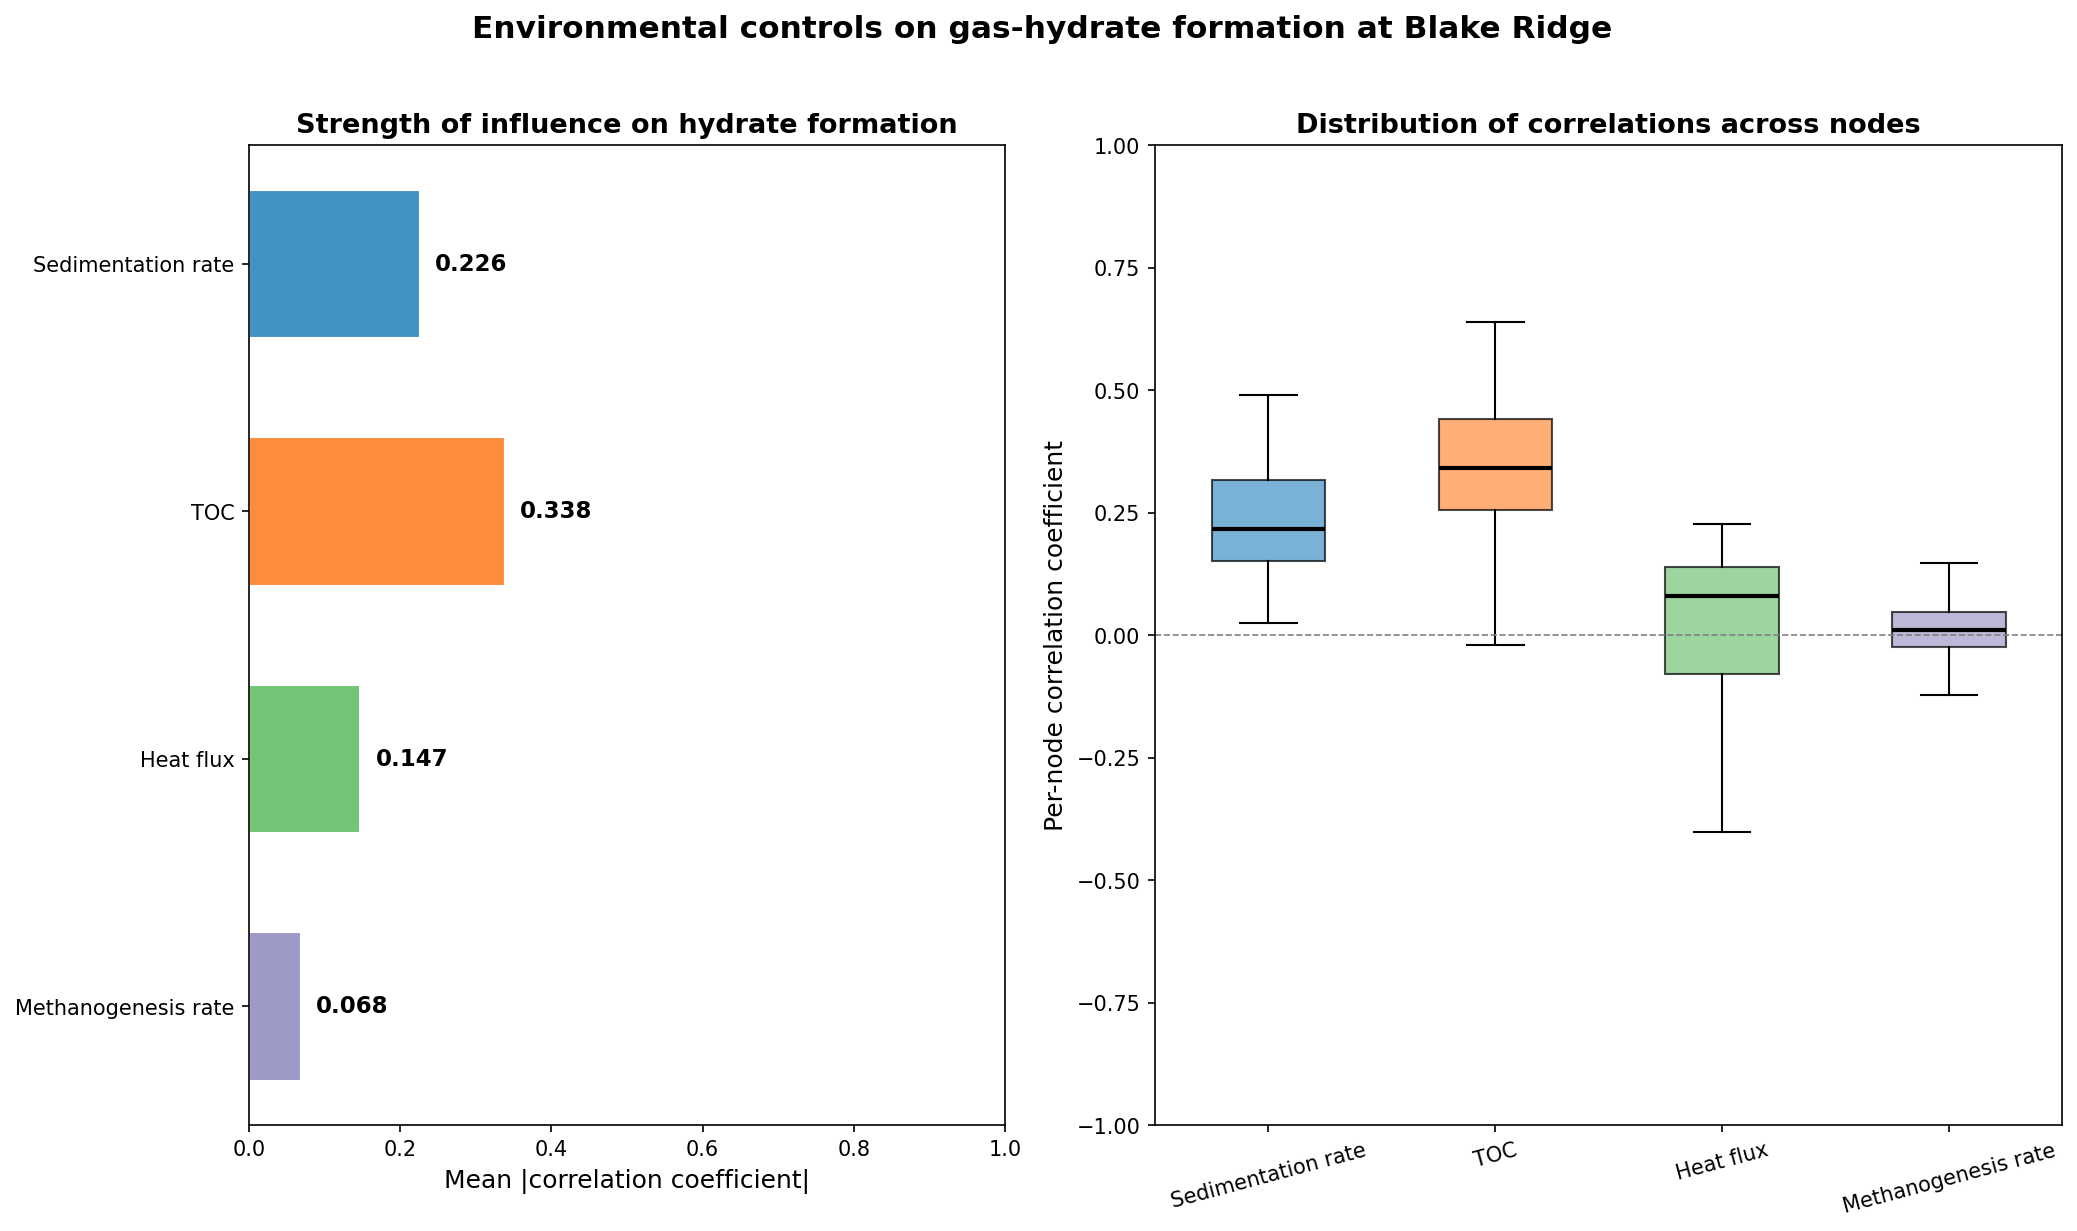

In [6]:
%%ask
Which environmental factor most strongly influences hydrate formation
across the Blake Ridge study area? Look at the correlations between
hydrate mass and sedimentation rate, total organic carbon (TOC), heat
flux, and methanogenesis rate. Comment on whether one factor dominates
or whether the picture is mixed.

I'll consult the skill's documentation to understand the HDF5 archive structure for sediment profiles, then build the depth-profile visualization.

I have the skill structure. Node 7675 in `Figure_03` is the only site with all three quantities (hydrate saturation, gas saturation, AND temperature). Let me first inspect the HDF5 structure and node attributes, then pick a good simulation run.

Running the inspection script to see node 7675's attributes and find a good simulation run.

Node 7675 is an excellent choice — ranked #55 of 6,048 by hydrate mass, at 1,311 m water depth on the ridge. Let me convert the depth index to real meters using the pressure profile, then build the three-panel depth plot.

Running the plot script to generate the three-panel depth profile.

...

Let me verify the profile shape — the BGHSZ annotation at 135 m seems inconsistent with the hydrate peak at 427 m. I need to check the actual depth profile values.

Critical finding: the profile arrays are stored **bottom-up** (index 0 = deepest point at 946 m, index 999 = seafloor at 0 m). The hydrate sits in the middle of the column (141–428 m bsf) with free gas trapped *below* it — the classic gas-hydrate system geometry. I need to flip the arrays so the seafloor is at the top.

Now running the corrected plot with the depth axis properly oriented.

The depth axis is now correctly oriented and the BGHSZ is at a physically sensible 428 m. This was a multi-edit cycle that discovered a real data issue, so I'll record the lesson in Learnings.md before writing the final report.

Learnings recorded. Here is the sediment-column profile for a high-hydrate site.

## Sediment-column profile at a high-hydrate site

I selected **Node 7675** — a site near the crest of Blake Ridge at **−75.458°W, 34.625°N** in **1,311 m water depth** . Of the 6,048 study-area nodes it ranks **#55 by average hydrate mass** (`Hmass ≈ 1,093`), placing it firmly among the model's richest hydrate locations. The `Figure_03` group of the HDF5 archive holds 54 Monte-Carlo simulations at this exact node with full sediment-column physics. I picked **simulation #37** , the run with the single highest peak hydrate saturation across all 54.


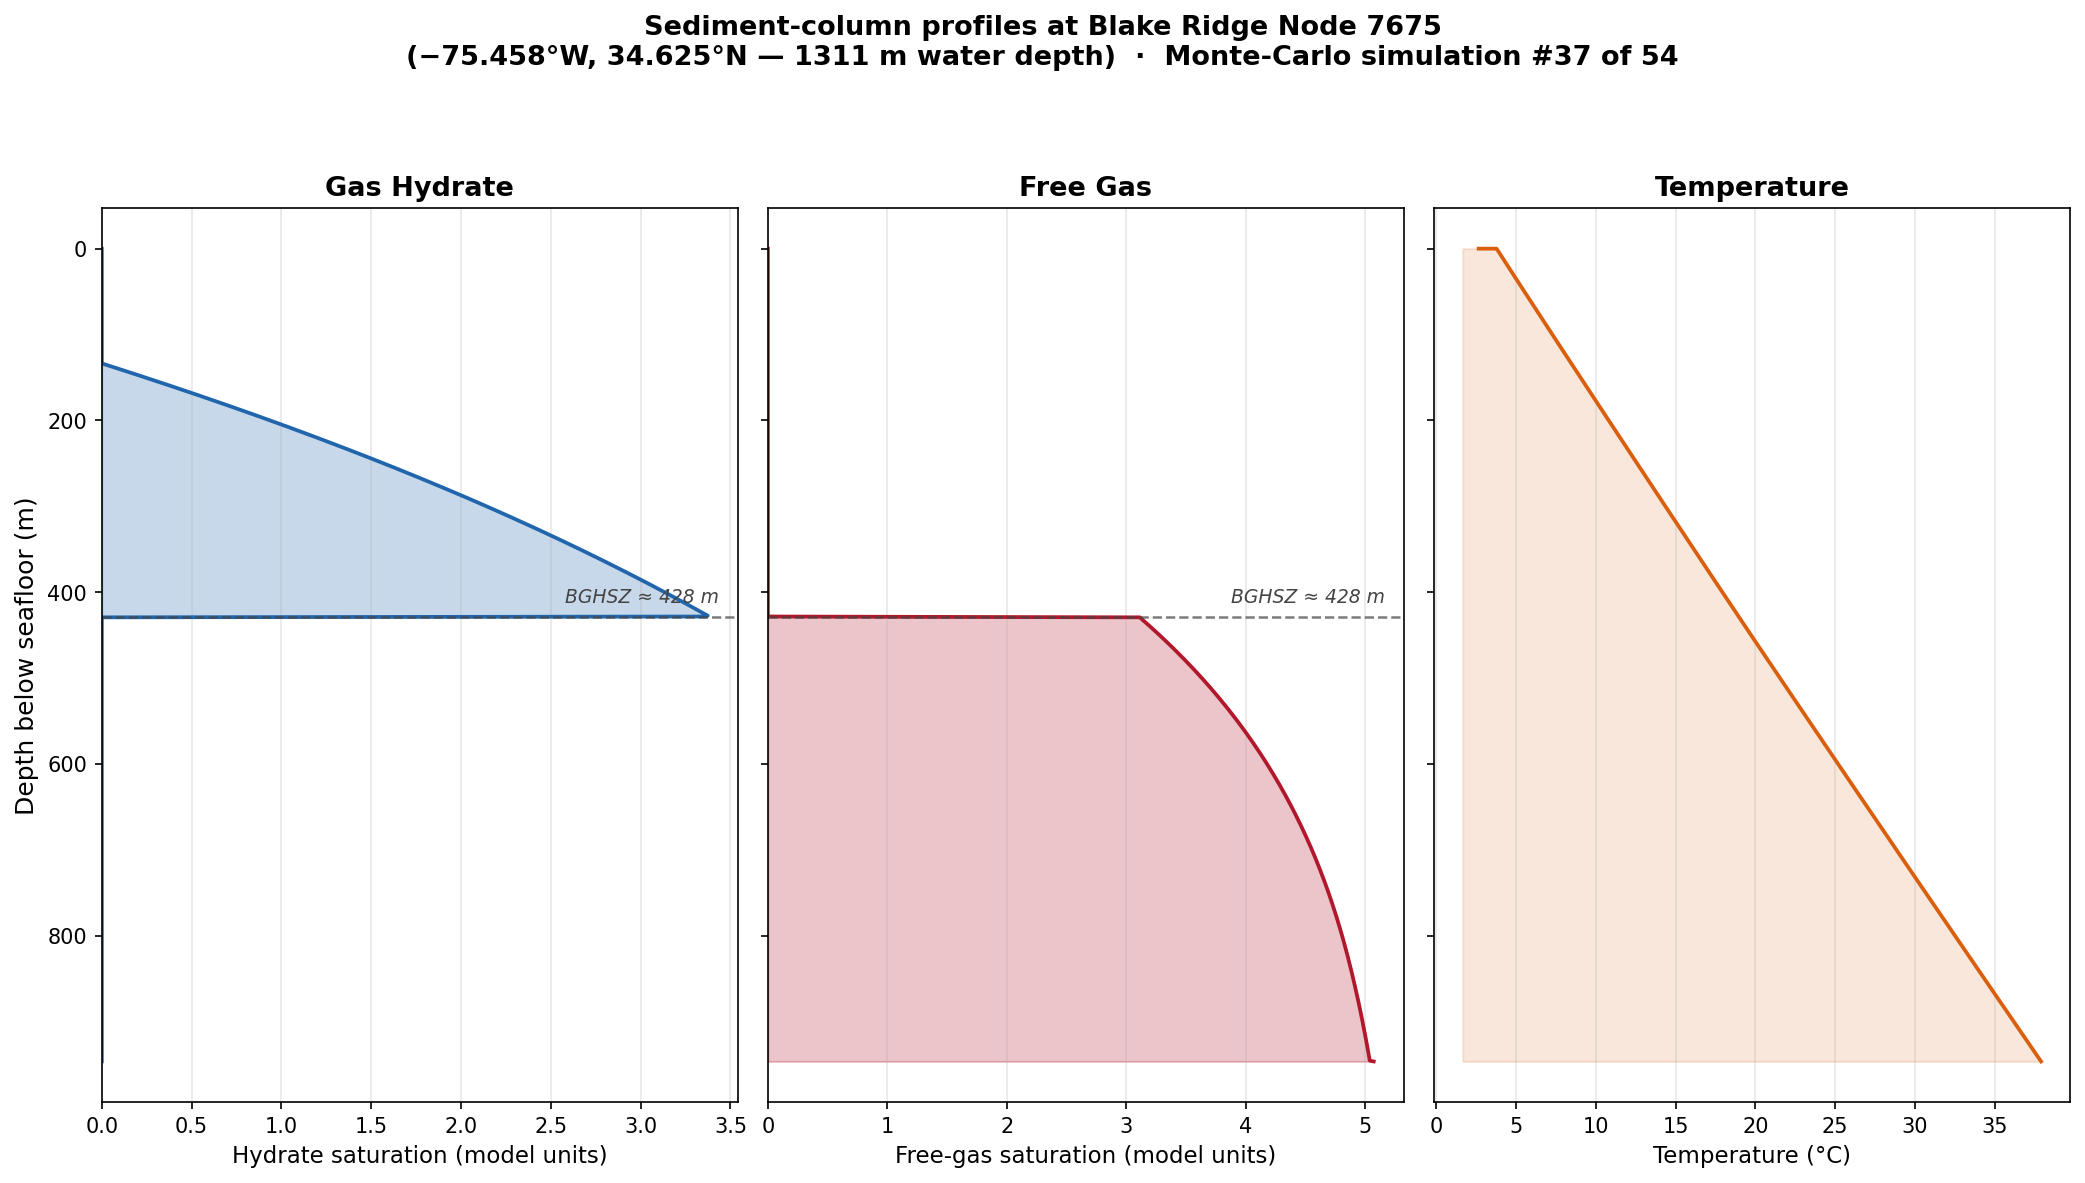

### What the profile shows

| Quantity | Key value | Depth below seafloor |
|---|---|---|
| Hydrate peak | 3.37 (model units) | ~427 m bsf |
| Free-gas peak | 5.07 (model units) | base of column (~946 m) |
| Seafloor temperature | 2.65 °C | 0 m |
| Base-of-column temperature | 37.9 °C | ~946 m |
| **BGHSZ** (base of gas-hydrate stability) | — | **~428 m bsf** |

The three panels reveal the classic architecture of a marine gas-hydrate system:

- **Gas hydrate (left)** occupies a distinct **mid-column band from ~140 to ~430 m below the seafloor** , peaking near the base. The dashed line marks the **base of the gas-hydrate stability zone (BGHSZ) at ~428 m** — below this depth, temperature and pressure conditions no longer support the solid hydrate structure.

- **Free gas (middle)** is concentrated **entirely *below* the hydrate band**, accumulating toward the base of the modeled column. This is the expected signature of methane gas trapped beneath the hydrate stability zone, sealed from above by the hydrate-bearing layer — the same geometry targeted by drilling at nearby ODP Site 997.

- **Temperature (right)** increases smoothly and near-linearly with depth from ~2.7 °C at the seafloor to ~38 °C at the base, driven by the local geothermal heat flux (59.9 mW/m² at this node). It is this steady rise in temperature, crossing the phase-boundary curve, that ultimately limits hydrate stability to the upper ~430 m of sediment.

### A note on units

The SKILL.md describes hydrate and gas "saturation" as 0–1 pore-volume fractions. In practice the stored values for these Monte-Carlo runs substantially exceed 1.0 — the Bhatnagar analytical reference solution in the same archive peaks at hydrate ≈ 4.2 and gas ≈ 7.0 — so I have labeled the axes conservatively as **model units** rather than percentages. The relative structure (where hydrate sits, where gas sits, the BGHSZ boundary) is robust regardless of the absolute scale.

In [7]:
%%ask
Pick one of the sites where the model predicts a lot of hydrate
formed. Show me how hydrate saturation, gas saturation, and
temperature vary with depth through the sediment column for one of
the simulation runs at that site.

Never read any png files because LLM is text only.

I'll check the skill and existing learnings, then build the overlay plot of all 54 Monte-Carlo runs.

Let me read more of the SKILL.md to understand the exact HDF5 structure of Figure_03 (the profile group).

I have the skill structure and the prior learnings. Now I'll write a script to overlay all 54 hydrate profiles from Figure_03, applying the bottom-up reversal and "model units" labeling from the learnings.

The script ran cleanly on the first try — no lessons to record. Here are the results.

## Ensemble spread across 54 Monte-Carlo runs at Profile 7675

The ensemble is **not** tightly clustered — it spans a **very wide range** , with dramatically bimodal behavior. This is one of the most important takeaways from the probabilistic modeling approach: whether hydrate forms *at all* is itself uncertain.

### Headline numbers

| Statistic (peak hydrate saturation per run) | Value |
|---|---|
| Minimum | 0.00 (no hydrate) |
| Maximum | 3.37 (model units) |
| Median | 0.40 |
| Mean | 0.78 |
| Std deviation | 0.89 |
| **Coefficient of variation** | **1.14** |

A coefficient of variation above 1.0 means the spread *exceeds* the mean — this is extreme variability, the opposite of a tightly clustered ensemble.

### The bimodal split

| Outcome | Runs | Fraction |
|---|---|---|
| **Near-zero hydrate** (peak < 0.1) | 27 | **50%** |
| **Substantial hydrate** (peak ≥ 0.1) | 27 | **50%** |

**Exactly half of the 54 parameter draws produce essentially no gas hydrate at this site** , while the other half produce meaningful accumulations. Among the hydrate-producing runs, peak saturation ranges up to 3.37 model units, and the depth of the peak ranges from the seafloor down to ~538 m below seafloor (median ~110 m).

### What this means physically

This bimodality is the signature of a **threshold system** . Gas-hydrate formation depends on methane supply (from TOC-driven methanogenesis), sedimentation rate, and the pressure-temperature stability window. Many combinations of these parameter draws simply don't cross the threshold for hydrate to nucleate and persist — the methane either stays dissolved, escapes, or never gets generated in sufficient quantity. But once a draw tips past that threshold, the system produces substantial hydrate. The probabilistic reservoir simulation is quantifying exactly this: not a single deterministic answer, but a **probability of formation** and a **conditional distribution of how much** .


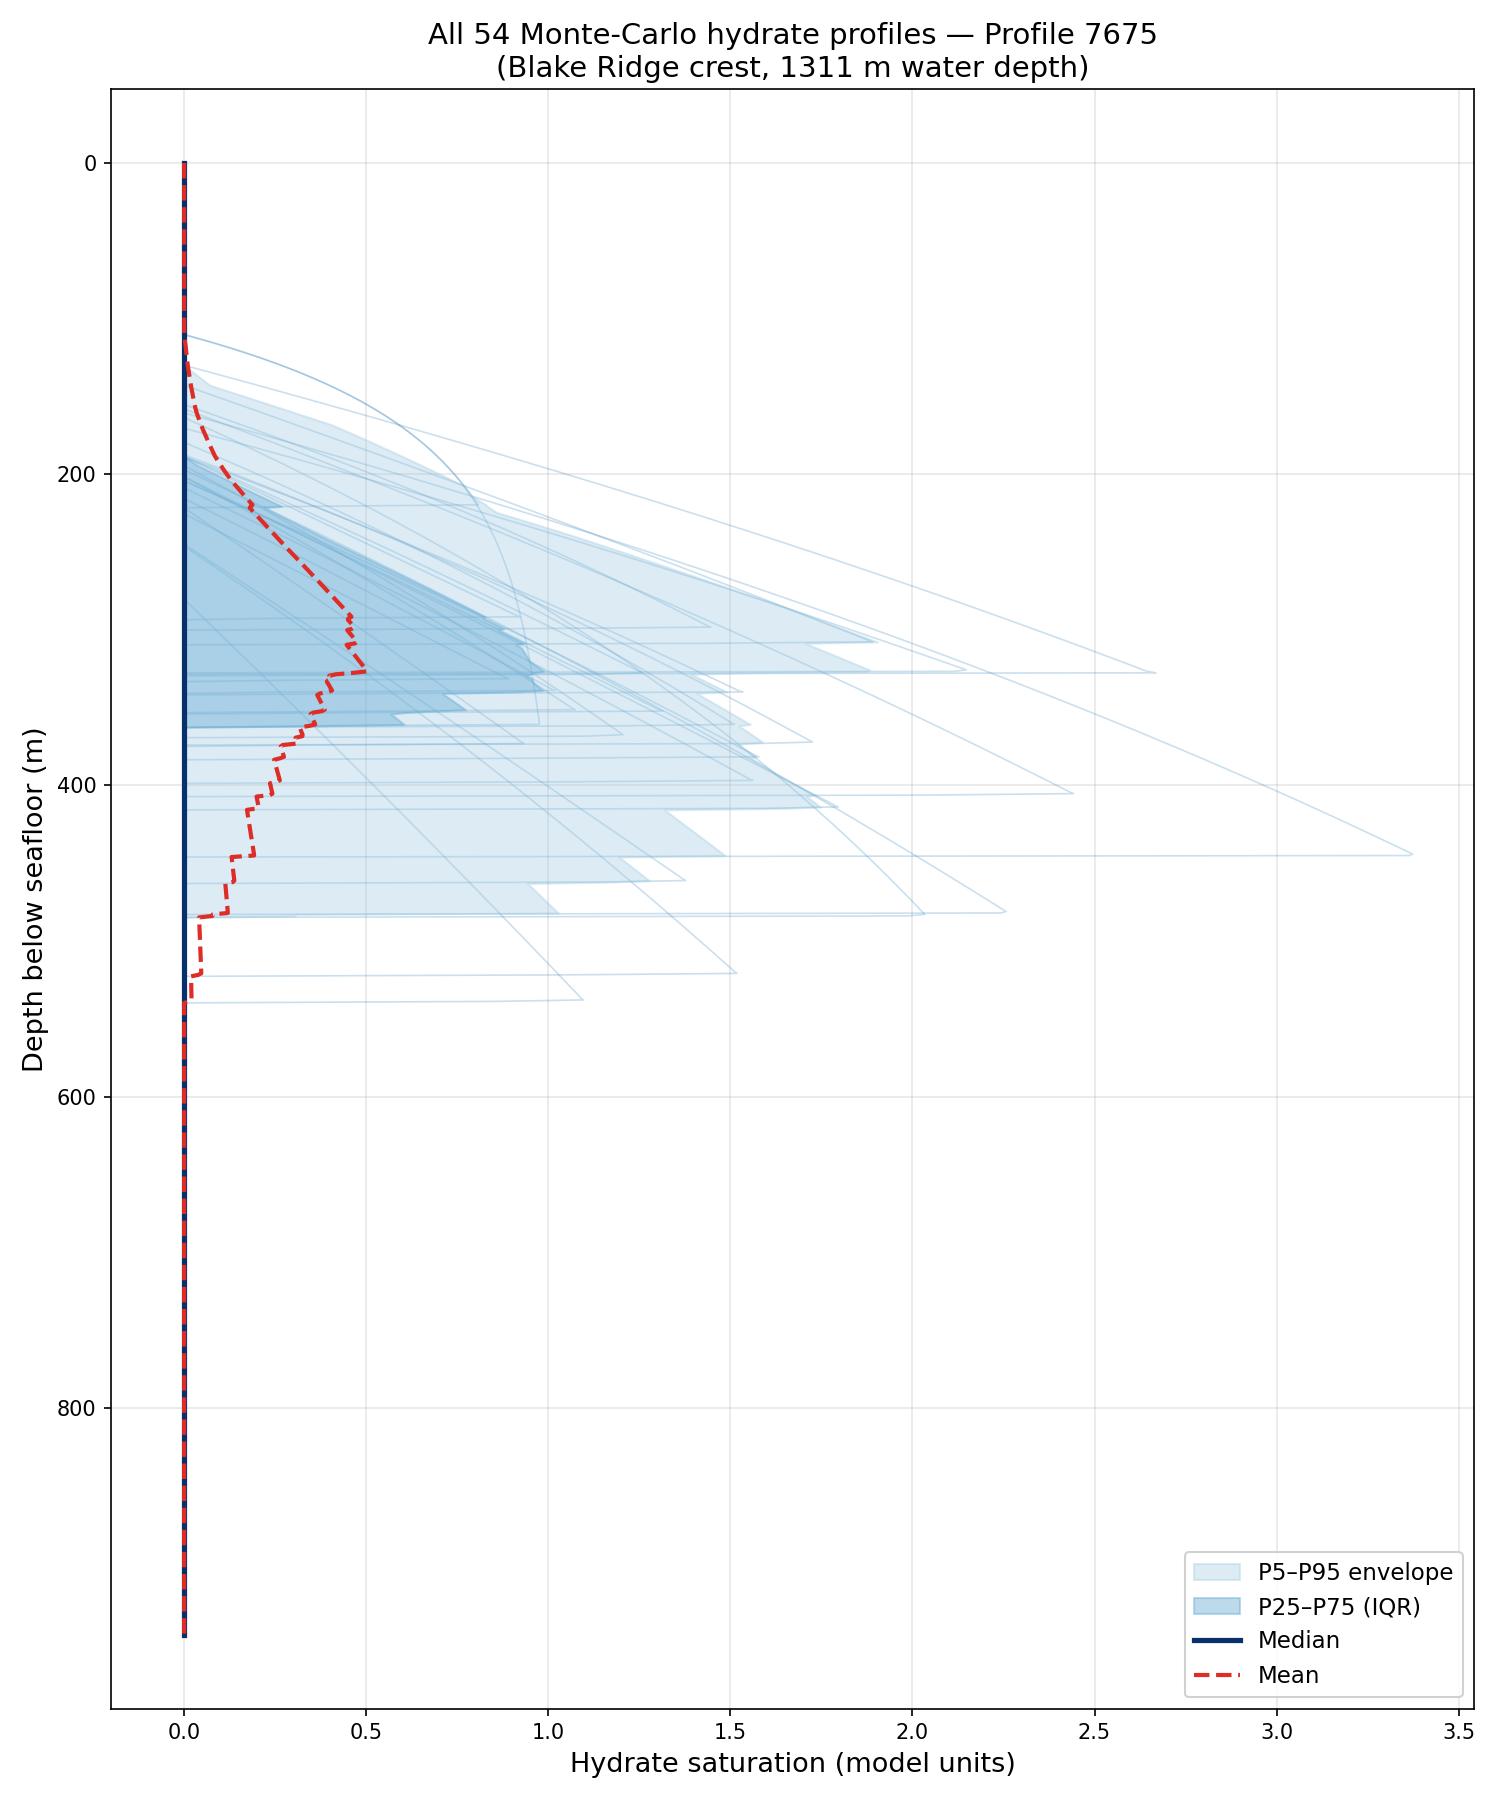

The plot overlays all 54 individual runs (thin blue lines) with a shaded P5–P95 envelope, an interquartile (P25–P75) band, and the median (dark blue) and mean (red dashed) profiles. The wide vertical spread of the envelope — and the flatlining of half the runs at zero — visually confirms that the ensemble is far from tightly clustered.

In [8]:
%%ask
At Profile 7675, the model was run 54 times with different parameter
draws. Overlay the hydrate saturation depth profiles for all 54
Monte-Carlo runs on a single plot so I can see how much the
predictions vary. Comment on whether the ensemble is tightly clustered
or spans a wide range.

I'll start by reviewing the skill and its learnings, then check what I've already explored in the HDF5 archive.

The skill and learnings are loaded. The `Figure_11/Bhatnagar` group has exactly what I need: `Exact_Hydrate` (analytical) plus `Hydrate_01`–`_92` (PFLOTRAN Monte-Carlo runs at ODP Site 997). Let me first explore that group to confirm its contents and check for a depth coordinate.

Figure_11/Bhatnagar confirmed: 92 PFLOTRAN MC runs + exact analytical solution, all `(1000,)`, stored bottom-up per the learnings. Let me probe the vertical structure of the exact solution to locate the hydrate stability zone and gas band, which will let me build a physically meaningful depth axis.

Excellent — the structure is crystal clear now. The exact Bhatnagar solution places hydrate in a band whose base sits at the BGHSZ (~450 m), with gas below. Notably, 89/92 MC runs produce substantial hydrate here (vs. the 50% at Profile 7675). Let me build the comparison plot with representative runs and quantitative agreement metrics.

The comparison is complete. The plot overlays the exact Bhatnagar analytical solution against 92 PFLOTRAN Monte-Carlo runs (with 7 representative runs highlighted individually).

## PFLOTRAN vs. Bhatnagar analytical — ODP Site 997

### Headline agreement

Both the analytical solution and the PFLOTRAN ensemble reproduce the **same fundamental architecture** : a hydrate band in the upper ~130–450 m of the column, with free gas below the base of the gas-hydrate stability zone (BGHSZ ≈ 450 m). **89 of 92 MC runs produce substantial hydrate here** — far more consistent than the 50% formation rate at Profile 7675, because ODP Site 997 sits squarely in the hydrate stability window with favorable TOC and sedimentation.

| Metric | Bhatnagar analytical | PFLOTRAN MC ensemble |
|---|---|---|
| Peak hydrate | **4.207** at 450 mbsf | min 0.00, **median 2.49** , mean 2.48, **max 4.71** |
| Peak depth | 450 mbsf | median 457, range 0–478 mbsf |
| Best run RMSE vs. exact | — | **0.000** (near-perfect match exists) |
| Median run RMSE vs. exact | — | 1.234 |

The analytical solution sits near the **upper edge** of the PFLOTRAN distribution — the best-matching run reproduces it almost exactly, but the median MC run underestimates the peak by ~40%.

### Where they agree and disagree most

| Depth zone | Exact mean | MC median mean | Agreement |
|---|---|---|---|
| Shallow (0–130 mbsf, above stability) | 0.000 | 0.000 | **Perfect** — no hydrate in either |
| Upper hydrate band (130–300 m) | 1.165 | 0.372 | **Underpredicts** (MC ~3× lower) |
| Mid hydrate band (300–450 m) | 3.272 | 1.743 | **Largest disagreement** (diff −1.53) |
| Base / BGHSZ (~450 m) | 0.136 | 0.521 | Slight MC overprediction at the tail |
| Below BGHSZ (>480 m, gas zone) | 0.000 | 0.000 | **Perfect** — no hydrate in either |

- **Agreement is strongest at the two ends of the column** — the shallow section above the stability zone and the deep section below the BGHSZ are both correctly zero in both solutions. Critically, **all 92 runs place the BGHSZ in nearly the same place** (~450–480 mbsf), confirming PFLOTRAN faithfully reproduces the depth of the phase boundary that governs the whole system.

- **Disagreement is concentrated in the mid-column (300–450 m)** , where the exact solution builds toward its peak (4.2) but the median MC run reaches only ~1.7. This is where the choice of input parameters — TOC, sedimentation rate, heat flux — most strongly controls *how much* hydrate accumulates within the stability window. The analytical solution is essentially one "best estimate" deterministic draw; PFLOTRAN's probabilistic spread shows that the amount of hydrate in this zone is the least certain part of the prediction.

- **The shape matches; the amplitude varies.** Individual MC runs span the full range from near-zero to slightly *exceeding* the analytical curve, so the analytical solution is not an outlier — it is a plausible single realization. The value of the Monte-Carlo approach is that it quantifies this amplitude uncertainty, which a single analytical curve cannot.


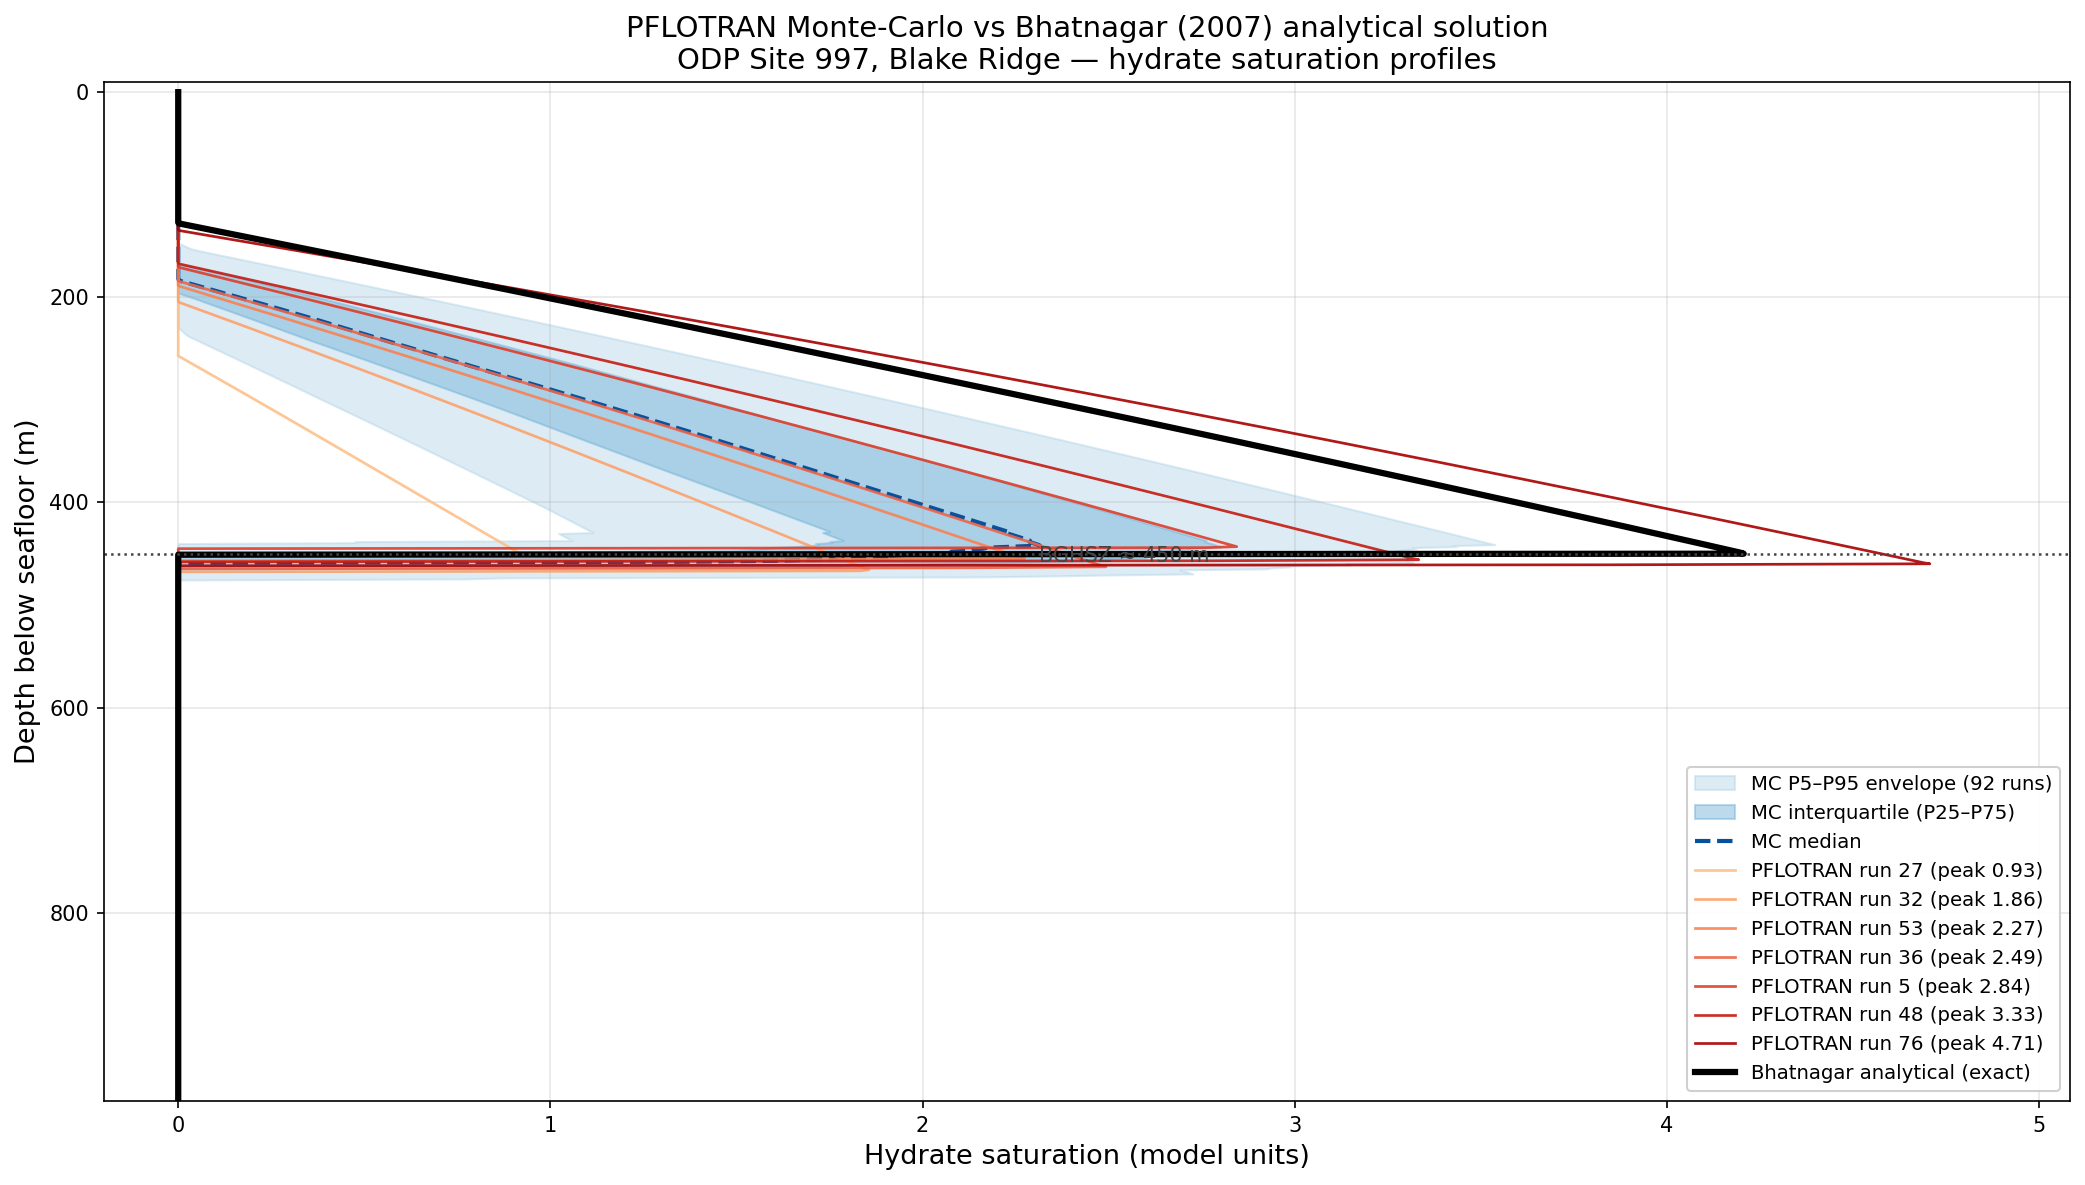

In [9]:
%%ask
For ODP Site 997, the paper compares the PFLOTRAN simulations against
Bhatnagar's (2007) analytical solution. Plot the exact Bhatnagar
hydrate profile against a few of the Monte-Carlo simulation profiles
so I can see how well the PFLOTRAN reproduces the analytical result.
Where along the depth column do they agree and disagree most?